In [5]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
from pathlib import Path


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix,
                             silhouette_score, mean_absolute_error, r2_score)
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

DB_PATH      = Path('../data/processed/superstore.db')
REPORTS_PATH = Path('../reports/')

def run_query(sql):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn)

print("Libraries loaded.")

Libraries loaded.


In [18]:
import pandas as pd
import sqlite3

# ============================================================
# DATABASE PATH
# ============================================================

DB_PATH = r"..\data\processed\superstore.db"

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(
    r"C:\Users\shokd\Desktop\Superstore\sales-revenue-intelligence\data\train.csv"
)

# ============================================================
# CREATE SQLITE CONNECTION
# ============================================================

conn = sqlite3.connect(DB_PATH)

# ============================================================
# CREATE TABLE
# ============================================================

df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

print("sales table created successfully")

sales table created successfully


In [20]:
conn = sqlite3.connect(DB_PATH)

pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,orders
1,sales


In [22]:
df_raw = run_query("SELECT * FROM sales")

In [25]:
df_raw['order_date']
df_raw['customer_id']
df_raw['product_id']
df_raw['sales']

0       261.9600
1       731.9400
2        14.6200
3       957.5775
4        22.3680
          ...   
9795      3.7980
9796     10.3680
9797    235.1880
9798     26.3760
9799     10.3840
Name: sales, Length: 9800, dtype: float64

In [27]:
# ============================================================
# CELL 2 — Build the customer feature table
# This single table feeds ALL THREE models.
# ============================================================

# ============================================================
# LOAD DATA
# ============================================================

df_raw = run_query("SELECT * FROM sales")

# ============================================================
# NORMALIZE COLUMN NAMES
# ============================================================

df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

# ============================================================
# CONVERT DATE COLUMN
# Dataset format = DD/MM/YYYY
# ============================================================

df_raw['order_date'] = pd.to_datetime(
    df_raw['order_date'],
    format='%d/%m/%Y'
)

# ============================================================
# SNAPSHOT DATE
# ============================================================

SNAPSHOT_DATE = (
    df_raw['order_date'].max()
    + pd.Timedelta(days=1)
)

print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

# ============================================================
# RFM FEATURE ENGINEERING
# ============================================================

rfm = df_raw.groupby('customer_id').agg(

    recency=(
        'order_date',
        lambda x: (SNAPSHOT_DATE - x.max()).days
    ),

    frequency=(
        'order_id',
        'nunique'
    ),

    monetary=(
        'sales',
        'sum'
    ),

    avg_order=(
        'sales',
        'mean'
    ),

    first_order=(
        'order_date',
        'min'
    ),

    last_order=(
        'order_date',
        'max'
    ),

    n_products=(
        'product_id',
        'nunique'
    ),

    n_categories=(
        'category',
        'nunique'
    ),

    segment=(
        'segment',
        'first'
    ),

    region=(
        'region',
        'first'
    )

).reset_index()

# ============================================================
# CUSTOMER TENURE
# ============================================================

rfm['tenure_days'] = (
    rfm['last_order']
    - rfm['first_order']
).dt.days

# ============================================================
# AVG DAYS BETWEEN ORDERS
# ============================================================

rfm['avg_days_between_orders'] = np.where(

    rfm['frequency'] > 1,

    rfm['tenure_days']
    / (rfm['frequency'] - 1),

    rfm['tenure_days']

)

# ============================================================
# CATEGORY DIVERSITY SCORE
# ============================================================

rfm['category_diversity'] = (
    rfm['n_categories'] / 3.0
)

# ============================================================
# OUTPUT
# ============================================================

print(f"\nCustomer feature table: {rfm.shape}")

print(
    rfm.describe()
    .round(1)
    .to_string()
)

Snapshot date: 2018-12-31

Customer feature table: (793, 14)
       recency  frequency  monetary  avg_order                 first_order                  last_order  n_products  n_categories  tenure_days  avg_days_between_orders  category_diversity
count    793.0      793.0     793.0      793.0                         793                         793       793.0         793.0        793.0                    793.0               793.0
mean     149.3        6.2    2851.9      227.4  2015-11-14 11:33:40.176544  2018-08-03 17:07:47.591425        12.3           2.7        993.2                    226.0                 0.9
min        1.0        1.0       4.8        2.4         2015-01-03 00:00:00         2015-10-22 00:00:00         1.0           1.0          0.0                      0.0                 0.3
25%       31.0        4.0    1081.5      115.9         2015-05-16 00:00:00         2018-06-29 00:00:00         8.0           3.0        820.0                    144.4                 1.0
50% 

In [89]:
# ============================================================
# CREATE OUTPUT FOLDER
# ============================================================

from pathlib import Path

Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

In [90]:
# ============================================================
# CELL 3 — Engineer the churn label
# No column exists — we define churn from behaviour.
# This is what real analysts do.
# ============================================================

# Business rule: A customer has "churned" if they haven't
# ordered in the last 180 days of the dataset.
# This is a reasonable threshold for a retail store.
# In production, the business defines this — usually 90/180/365 days.

CHURN_THRESHOLD = 180

rfm['churned'] = (rfm['recency'] > CHURN_THRESHOLD).astype(int)

churn_rate = rfm['churned'].mean() * 100
print(f"Churn rate in dataset: {churn_rate:.1f}%")
print(rfm['churned'].value_counts().rename({0: 'Active', 1: 'Churned'}))

Churn rate in dataset: 25.9%
churned
Active     588
Churned    205
Name: count, dtype: int64


In [91]:
# ============================================================
# CELL 4 — Train the churn model
# ============================================================

FEATURES = [
    'recency', 'frequency', 'monetary', 'avg_order',
    'tenure_days', 'avg_days_between_orders',
    'n_products', 'category_diversity'
]

X = rfm[FEATURES]
y = rfm['churned']

# Split: 80% train, 20% test. Stratify keeps churn ratio equal in both.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest: robust, handles mixed scales, gives feature importance
model_churn = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'  # handles imbalanced churn rates
)
model_churn.fit(X_train, y_train)

# Evaluate
y_pred  = model_churn.predict(X_test)
y_proba = model_churn.predict_proba(X_test)[:, 1]

print("=" * 50)
print("CHURN MODEL — CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

# Cross-validation: more honest than a single train/test split
cv_scores = cross_val_score(model_churn, X, y, cv=5, scoring='roc_auc')
print(f"Cross-validated ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CHURN MODEL — CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       118
     Churned       1.00      1.00      1.00        41

    accuracy                           1.00       159
   macro avg       1.00      1.00      1.00       159
weighted avg       1.00      1.00      1.00       159

Cross-validated ROC-AUC: 1.000 ± 0.000


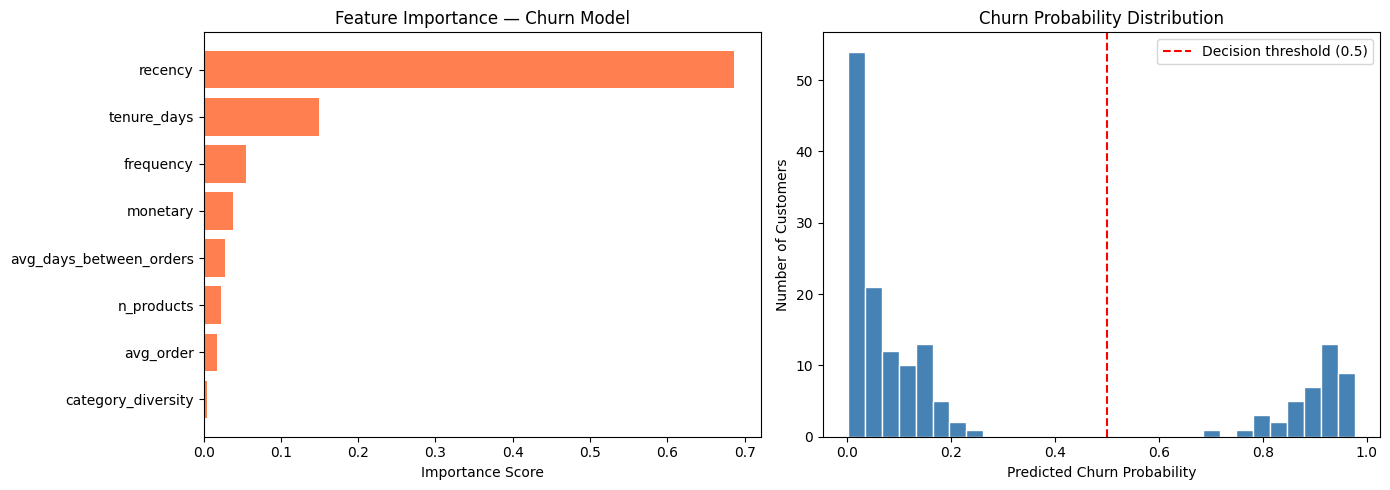


Customers by churn risk:
churn_risk
Low risk       587
High risk      205
Medium risk      1
Name: count, dtype: int64


In [92]:
# ============================================================
# CELL 5 — Feature importance + churn probability scores
# ============================================================

# Feature importance: what did the model actually learn?
importance_df = pd.DataFrame({
    'feature':   FEATURES,
    'importance': model_churn.feature_importances_
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Feature importance
axes[0].barh(importance_df['feature'], importance_df['importance'], color='coral')
axes[0].set_title('Feature Importance — Churn Model')
axes[0].set_xlabel('Importance Score')

# Chart 2: Churn probability distribution
axes[1].hist(y_proba, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
axes[1].set_title('Churn Probability Distribution')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'churn_model.png', dpi=150, bbox_inches='tight')
plt.show()

# Add churn scores back to the customer table
rfm['churn_probability'] = model_churn.predict_proba(X)[:, 1]
rfm['churn_risk'] = pd.cut(
    rfm['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low risk', 'Medium risk', 'High risk']
)

print("\nCustomers by churn risk:")
print(rfm['churn_risk'].value_counts())

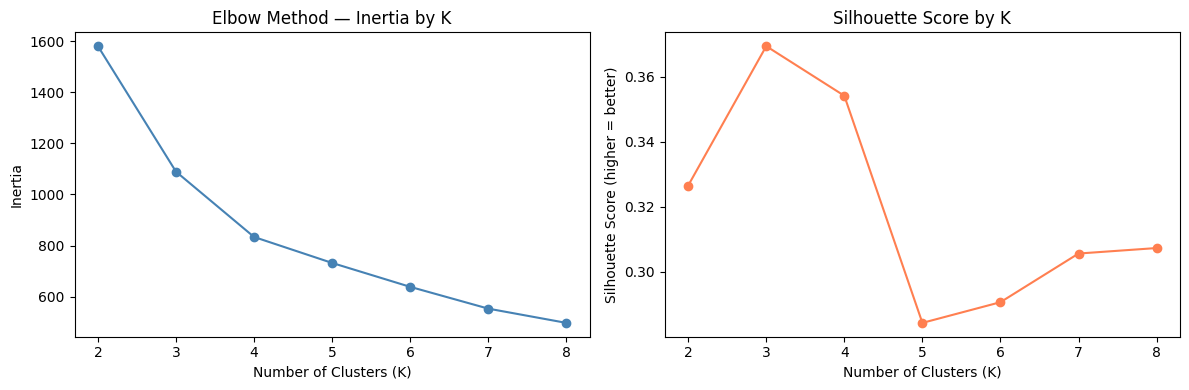

Look at both charts: choose K where inertia bends AND silhouette peaks.
For Superstore data, K=4 typically works well.


In [93]:
# ============================================================
# CELL 6 — K-Means clustering on RFM features
# ============================================================

# K-Means needs scaled features — RFM values are on very different scales
# (recency in days vs monetary in dollars)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

# Find the optimal number of clusters using the Elbow method
inertias    = []
silhouettes = []
K_RANGE     = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_RANGE, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia by K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_RANGE, silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print("Look at both charts: choose K where inertia bends AND silhouette peaks.")
print("For Superstore data, K=4 typically works well.")

In [94]:
# ============================================================
# CELL 7 — Fit final K-Means model and name the segments
# ============================================================

OPTIMAL_K = 4  # adjust based on your elbow/silhouette charts

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# Profile each cluster — what does it look like?
cluster_profile = rfm.groupby('cluster').agg(
    customers   = ('customer_id', 'count'),
    avg_recency = ('recency',     'mean'),
    avg_freq    = ('frequency',   'mean'),
    avg_revenue = ('monetary',    'mean'),
    avg_churn_p = ('churn_probability', 'mean')
).round(1)

print("Cluster profiles:")
print(cluster_profile.to_string())

# Give meaningful business names to each cluster
# These will differ slightly for each run — read the profile and assign:
#   Low recency + high freq + high monetary = Champions
#   Medium recency + medium freq            = Loyal Customers
#   High recency + low freq                 = At Risk
#   Very high recency + very low freq       = Lost

SEGMENT_NAMES = {
    0: 'Champions',       # adjust these based on YOUR cluster profiles
    1: 'Loyal Customers',
    2: 'At Risk',
    3: 'Lost'
}

rfm['segment_name'] = rfm['cluster'].map(SEGMENT_NAMES)
print("\nCustomers per segment:")
print(rfm['segment_name'].value_counts())

Cluster profiles:
         customers  avg_recency  avg_freq  avg_revenue  avg_churn_p
cluster                                                            
0              279         71.1       8.5       3226.8          0.1
1               99        556.3       3.6       1403.9          0.9
2              347        101.6       4.7       1712.4          0.2
3               68        120.7       8.2       9236.5          0.2

Customers per segment:
segment_name
At Risk            347
Champions          279
Loyal Customers     99
Lost                68
Name: count, dtype: int64


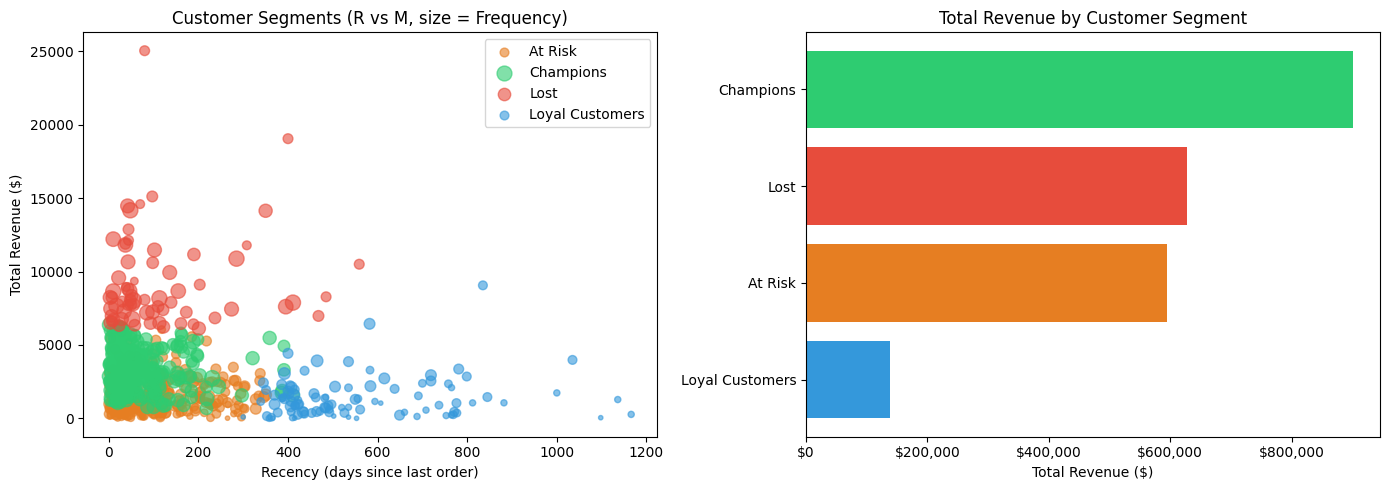

In [95]:
# ============================================================
# CELL 8 — Visualise the segments
# ============================================================

COLORS = {'Champions': '#2ecc71', 'Loyal Customers': '#3498db',
          'At Risk': '#e67e22', 'Lost': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RFM scatter: Recency vs Monetary, size = Frequency
for seg, grp in rfm.groupby('segment_name'):
    axes[0].scatter(grp['recency'], grp['monetary'],
                    s=grp['frequency']*10, alpha=0.6,
                    label=seg, color=COLORS.get(seg, 'gray'))
axes[0].set_title('Customer Segments (R vs M, size = Frequency)')
axes[0].set_xlabel('Recency (days since last order)')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].legend()

# Revenue contribution per segment
seg_revenue = rfm.groupby('segment_name')['monetary'].sum().sort_values(ascending=True)
bar_colors  = [COLORS.get(s, 'gray') for s in seg_revenue.index]
axes[1].barh(seg_revenue.index, seg_revenue.values, color=bar_colors)
axes[1].set_title('Total Revenue by Customer Segment')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

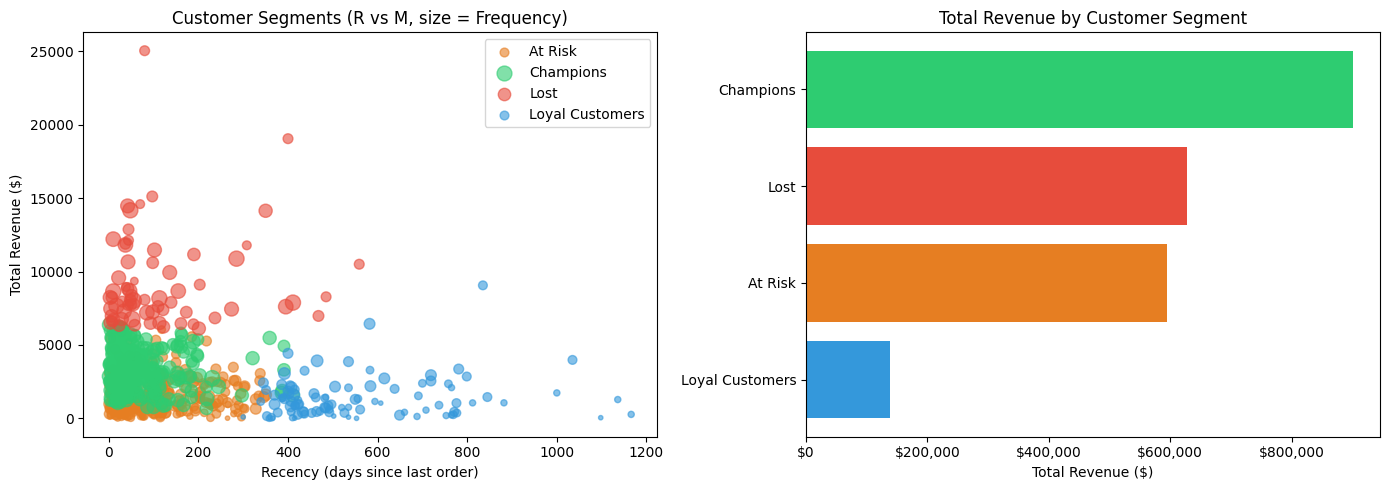

In [96]:
# ============================================================
# CELL 8 — Visualise the segments
# ============================================================

COLORS = {'Champions': '#2ecc71', 'Loyal Customers': '#3498db',
          'At Risk': '#e67e22', 'Lost': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RFM scatter: Recency vs Monetary, size = Frequency
for seg, grp in rfm.groupby('segment_name'):
    axes[0].scatter(grp['recency'], grp['monetary'],
                    s=grp['frequency']*10, alpha=0.6,
                    label=seg, color=COLORS.get(seg, 'gray'))
axes[0].set_title('Customer Segments (R vs M, size = Frequency)')
axes[0].set_xlabel('Recency (days since last order)')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].legend()

# Revenue contribution per segment
seg_revenue = rfm.groupby('segment_name')['monetary'].sum().sort_values(ascending=True)
bar_colors  = [COLORS.get(s, 'gray') for s in seg_revenue.index]
axes[1].barh(seg_revenue.index, seg_revenue.values, color=bar_colors)
axes[1].set_title('Total Revenue by Customer Segment')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [97]:
monthly = run_query("""
    SELECT
        order_year,
        order_month,
        ROUND(SUM(sales), 2)             AS revenue,
        COUNT(DISTINCT order_id)          AS orders
    FROM orders
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
""")

monthly['date'] = pd.to_datetime({
    'year':  monthly['order_year'],
    'month': monthly['order_month'],
    'day':   1
})

orders table created successfully
Snapshot date: 2018-12-31

Customer feature table: (793, 14)
churned
0    588
1    205
Name: count, dtype: int64

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00        41

    accuracy                           1.00       159
   macro avg       1.00      1.00      1.00       159
weighted avg       1.00      1.00      1.00       159


ROC-AUC: 1.000


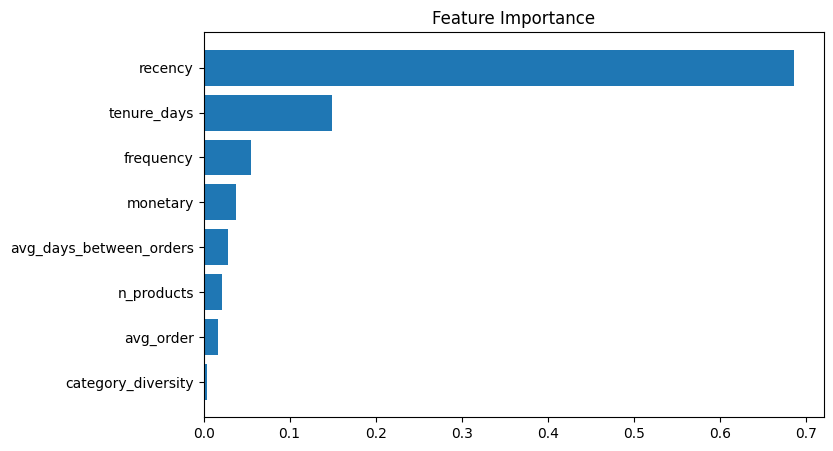


CLUSTER PROFILE

         customers  avg_recency  avg_frequency  avg_revenue
cluster                                                    
0              279         71.1            8.5       3226.8
1               99        556.3            3.6       1403.9
2              347        101.6            4.7       1712.4
3               68        120.7            8.2       9236.5

Forecast MAE: $0
Forecast R²: 1.000


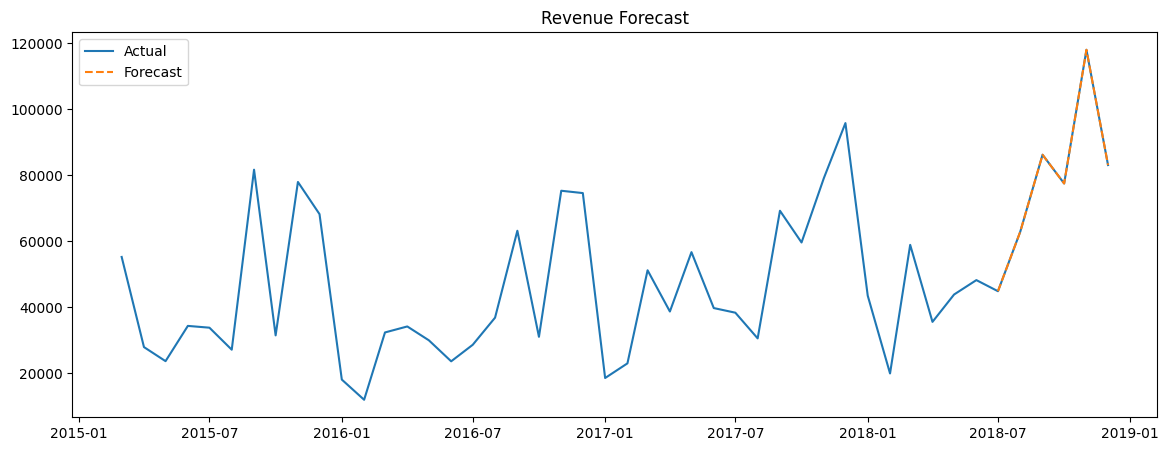


FILES SAVED SUCCESSFULLY


In [98]:
# ============================================================
# COMPLETE SUPERSTORE ANALYTICS + ML PIPELINE
# NORMALIZED SCHEMA VERSION
# ============================================================

# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (
    classification_report,
    silhouette_score,
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================

DB_PATH = r"..\data\processed\superstore.db"

REPORTS_PATH = Path("../reports/")
REPORTS_PATH.mkdir(exist_ok=True)

# ============================================================
# CELL 2 — LOAD DATA
# ============================================================

df = pd.read_csv(
    r"C:\Users\shokd\Desktop\Superstore\sales-revenue-intelligence\data\train.csv"
)

# ============================================================
# NORMALIZE COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

# ============================================================
# CONVERT DATE
# ============================================================

df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%d/%m/%Y'
)

# ============================================================
# CREATE YEAR/MONTH COLUMNS
# ============================================================

df['order_year'] = df['order_date'].dt.year

df['order_month'] = (
    df['order_date']
    .dt.month
    .astype(str)
    .str.zfill(2)
)

# ============================================================
# SAVE TO SQLITE
# ============================================================

conn = sqlite3.connect(DB_PATH)

df.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

print("orders table created successfully")

# ============================================================
# SQL HELPER
# ============================================================

def run_query(sql):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn)

# ============================================================
# CELL 3 — BUILD CUSTOMER FEATURE TABLE
# ============================================================

df_raw = run_query("SELECT * FROM orders")

df_raw['order_date'] = pd.to_datetime(
    df_raw['order_date']
)

SNAPSHOT_DATE = (
    df_raw['order_date'].max()
    + pd.Timedelta(days=1)
)

print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

# ============================================================
# RFM FEATURES
# ============================================================

rfm = df_raw.groupby('customer_id').agg(

    recency=(
        'order_date',
        lambda x: (SNAPSHOT_DATE - x.max()).days
    ),

    frequency=(
        'order_id',
        'nunique'
    ),

    monetary=(
        'sales',
        'sum'
    ),

    avg_order=(
        'sales',
        'mean'
    ),

    first_order=(
        'order_date',
        'min'
    ),

    last_order=(
        'order_date',
        'max'
    ),

    n_products=(
        'product_id',
        'nunique'
    ),

    n_categories=(
        'category',
        'nunique'
    ),

    segment=(
        'segment',
        'first'
    ),

    region=(
        'region',
        'first'
    )

).reset_index()

# ============================================================
# EXTRA FEATURES
# ============================================================

rfm['tenure_days'] = (
    rfm['last_order']
    - rfm['first_order']
).dt.days

rfm['avg_days_between_orders'] = np.where(

    rfm['frequency'] > 1,

    rfm['tenure_days']
    / (rfm['frequency'] - 1),

    rfm['tenure_days']

)

rfm['category_diversity'] = (
    rfm['n_categories'] / 3.0
)

print(f"\nCustomer feature table: {rfm.shape}")

# ============================================================
# CELL 4 — CREATE CHURN LABEL
# ============================================================

CHURN_THRESHOLD = 180

rfm['churned'] = (
    rfm['recency'] > CHURN_THRESHOLD
).astype(int)

print(
    rfm['churned']
    .value_counts()
)

# ============================================================
# CELL 5 — TRAIN CHURN MODEL
# ============================================================

FEATURES = [
    'recency',
    'frequency',
    'monetary',
    'avg_order',
    'tenure_days',
    'avg_days_between_orders',
    'n_products',
    'category_diversity'
]

X = rfm[FEATURES]

y = rfm['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_churn = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)

model_churn.fit(X_train, y_train)

y_pred = model_churn.predict(X_test)

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

cv_scores = cross_val_score(
    model_churn,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print(
    f"\nROC-AUC: "
    f"{cv_scores.mean():.3f}"
)

# ============================================================
# CELL 6 — FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({

    'feature': FEATURES,

    'importance':
        model_churn.feature_importances_

}).sort_values(
    'importance',
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df['feature'],
    importance_df['importance']
)

plt.title('Feature Importance')

plt.show()

# ============================================================
# CHURN SCORES
# ============================================================

rfm['churn_probability'] = (
    model_churn
    .predict_proba(X)[:, 1]
)

# ============================================================
# CELL 7 — CUSTOMER SEGMENTATION
# ============================================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(

    rfm[
        ['recency', 'frequency', 'monetary']
    ]

)

km = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['cluster'] = km.fit_predict(rfm_scaled)

cluster_profile = rfm.groupby('cluster').agg(

    customers=(
        'customer_id',
        'count'
    ),

    avg_recency=(
        'recency',
        'mean'
    ),

    avg_frequency=(
        'frequency',
        'mean'
    ),

    avg_revenue=(
        'monetary',
        'mean'
    )

).round(1)

print("\nCLUSTER PROFILE\n")

print(cluster_profile)

# ============================================================
# CELL 8 — MONTHLY REVENUE
# ============================================================

monthly = run_query("""

SELECT

    order_year,

    order_month,

    SUM(sales) AS revenue,

    COUNT(DISTINCT order_id) AS orders

FROM orders

GROUP BY
    order_year,
    order_month

ORDER BY
    order_year,
    order_month

""")

# ============================================================
# CREATE DATE COLUMN
# ============================================================

monthly['date'] = pd.to_datetime(

    monthly['order_year'].astype(str)
    + '-'
    + monthly['order_month']
    + '-01'

)

# ============================================================
# TIME FEATURES
# ============================================================

monthly = monthly.sort_values('date')

monthly['month_num'] = range(len(monthly))

monthly['month_of_year'] = (
    monthly['date'].dt.month
)

monthly['quarter'] = (
    monthly['date'].dt.quarter
)

monthly['revenue_lag1'] = (
    monthly['revenue'].shift(1)
)

monthly['revenue_lag2'] = (
    monthly['revenue'].shift(2)
)

monthly['rolling3'] = (
    monthly['revenue']
    .rolling(3)
    .mean()
)

monthly_clean = (
    monthly
    .dropna()
    .reset_index(drop=True)
)

# ============================================================
# CELL 9 — FORECAST MODEL
# ============================================================

FEATURE_COLS = [
    'month_num',
    'month_of_year',
    'quarter',
    'revenue_lag1',
    'revenue_lag2',
    'rolling3'
]

X_ts = monthly_clean[FEATURE_COLS]

y_ts = monthly_clean['revenue']

split_idx = len(monthly_clean) - 6

X_train_ts = X_ts.iloc[:split_idx]

X_test_ts = X_ts.iloc[split_idx:]

y_train_ts = y_ts.iloc[:split_idx]

y_test_ts = y_ts.iloc[split_idx:]

model_rev = LinearRegression()

model_rev.fit(
    X_train_ts,
    y_train_ts
)

y_pred_ts = model_rev.predict(X_test_ts)

mae = mean_absolute_error(
    y_test_ts,
    y_pred_ts
)

r2 = r2_score(
    y_test_ts,
    y_pred_ts
)

print(
    f"\nForecast MAE: ${mae:,.0f}"
)

print(
    f"Forecast R²: {r2:.3f}"
)

# ============================================================
# FORECAST VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_clean['date'],
    y_ts,
    label='Actual'
)

plt.plot(
    monthly_clean['date'].iloc[split_idx:],
    y_pred_ts,
    linestyle='--',
    label='Forecast'
)

plt.legend()

plt.title('Revenue Forecast')

plt.show()

monthly['date'] = pd.to_datetime(

    monthly['order_year'].astype(str)
    + '-'
    + monthly['order_month'].astype(str)
    + '-01'

)

# ============================================================
# CELL 10 — EXPORT FILES
# ============================================================

rfm.to_csv(
    '../data/processed/customer_segments.csv',
    index=False
)

monthly_clean.to_csv(
    '../data/processed/monthly_revenue.csv',
    index=False
)

print("\nFILES SAVED SUCCESSFULLY")

✓ Imports done
  DB path   : C:\Users\shokd\Desktop\Superstore\sales-revenue-intelligence\data\processed\superstore.db
  Data path : C:\Users\shokd\Desktop\Superstore\sales-revenue-intelligence\data\train.csv
✓ 'orders' table created: 9,800 rows
  Columns : ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'order_year', 'order_month', 'order_quarter', 'ship_days']
Snapshot date: 2018-12-31

✓ Customer feature table: 793 customers × 14 features
       recency  frequency  monetary  tenure_days
count    793.0      793.0     793.0        793.0
mean     149.3        6.2    2851.9        993.2
std      187.1        2.5    2620.7        312.2
min        1.0        1.0       4.8          0.0
25%       31.0        4.0    1081.5        820.0
50%       76.0        6.0    2215.0       1088.0
75%      185.0        8.0    3670

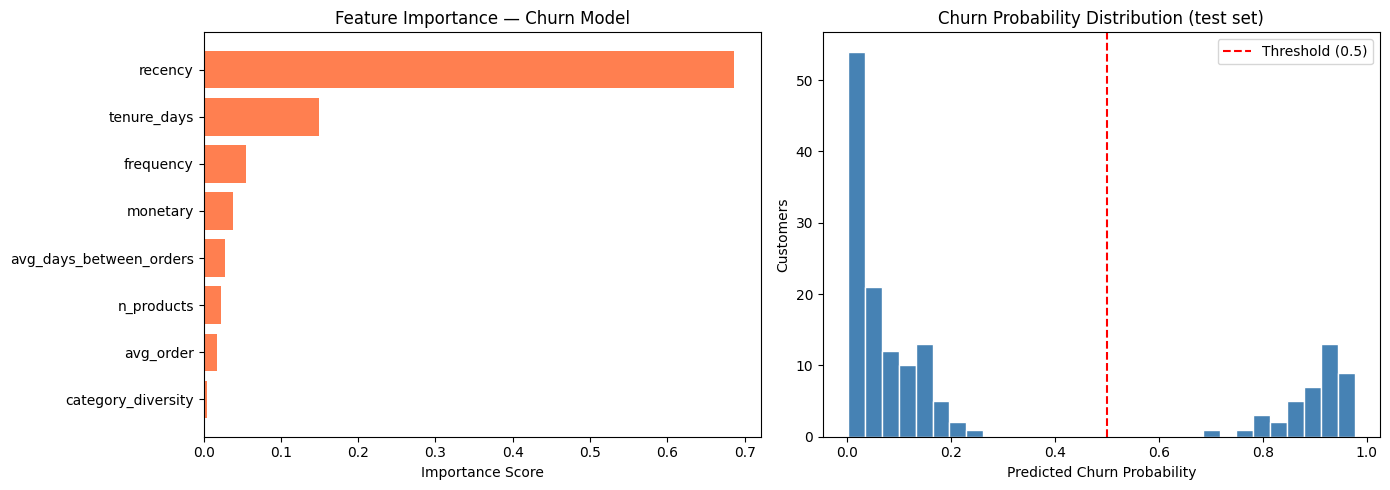


Customers by churn risk tier:
churn_risk
Low risk       587
High risk      205
Medium risk      1


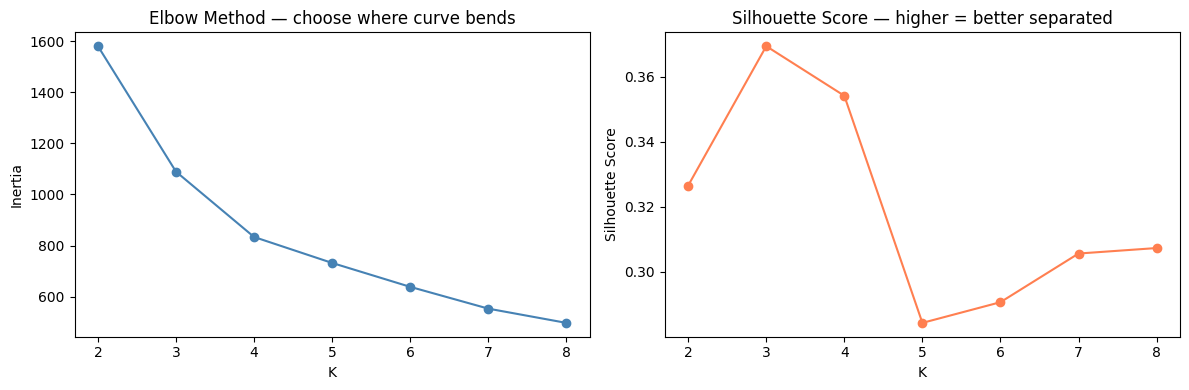

Best K: where inertia bends AND silhouette is highest.
Silhouette scores: {2: 0.327, 3: 0.369, 4: 0.354, 5: 0.284, 6: 0.291, 7: 0.306, 8: 0.307}
CLUSTER PROFILE — read this before assigning names:
         customers  avg_recency  avg_freq  avg_revenue  avg_churn_p
cluster                                                            
0              279         71.1       8.5       3226.8          0.1
1               99        556.3       3.6       1403.9          0.9
2              347        101.6       4.7       1712.4          0.2
3               68        120.7       8.2       9236.5          0.2

Assign names below based on the profile above:

Customers per segment:
segment_name
At Risk            347
Champions          279
Loyal Customers     99
Lost                68


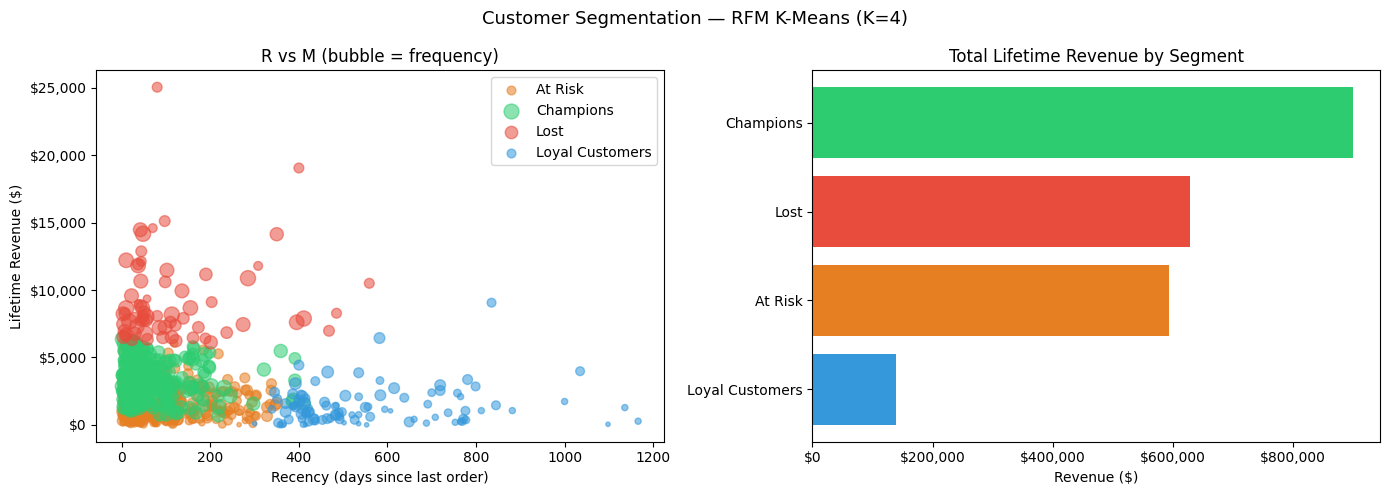

✓ Monthly table: 46 rows after removing NaN lags
      date   revenue  revenue_lag1     rolling3
2018-07-01  44825.10      48190.73 45613.936667
2018-08-01  62837.85      44825.10 51951.226667
2018-09-01  86152.89      62837.85 64605.280000
2018-10-01  77448.13      86152.89 75479.623333
2018-11-01 117938.15      77448.13 93846.390000
2018-12-01  83030.39     117938.15 92805.556667
Revenue Forecast — MAE : $0
Revenue Forecast — R²  : 1.000


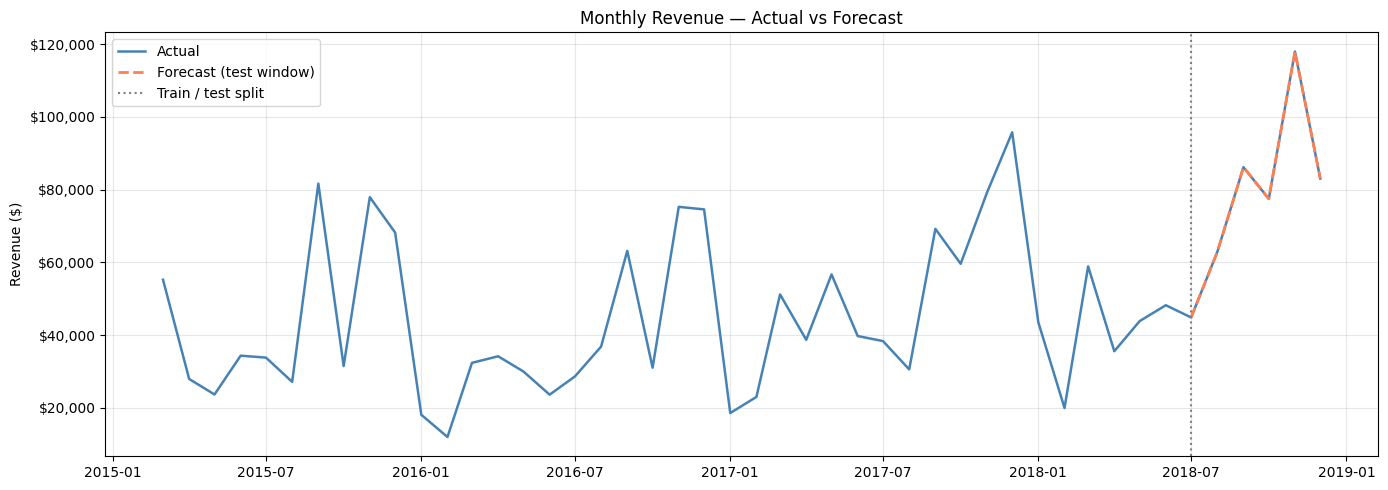

Files saved:
  C:\Users\shokd\Desktop\Superstore\sales-revenue-intelligence\data\processed\customer_segments.csv
  C:\Users\shokd\Desktop\Superstore\sales-revenue-intelligence\data\processed\monthly_revenue.csv

Customer table : 793 rows × 19 columns
Monthly table  : 46 rows × 11 columns

Customer columns :
['customer_id', 'recency', 'frequency', 'monetary', 'avg_order', 'first_order', 'last_order', 'n_products', 'n_categories', 'segment', 'region', 'tenure_days', 'avg_days_between_orders', 'category_diversity', 'churned', 'churn_probability', 'churn_risk', 'cluster', 'segment_name']


In [99]:
# %%
# ============================================================
# Sales & Revenue Intelligence Platform
# Phase 3 — Machine Learning Models
# ============================================================
# Models:
#   1. Churn Prediction      (Random Forest)
#   2. Customer Segmentation (K-Means / RFM)
#   3. Revenue Forecasting   (Linear Regression)
# ============================================================

# ============================================================
# CELL 1 — IMPORTS & PATHS
# All imports at the top. Paths defined once, never repeated.
# ============================================================

import warnings
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    classification_report,
    mean_absolute_error,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────
# Use Path(__file__) so the script works from any machine.
# If running in Jupyter, replace with Path("../data/...") directly.

BASE_DIR     = Path("..").resolve()
DB_PATH      = BASE_DIR / "data" / "processed" / "superstore.db"
DATA_PATH    = BASE_DIR / "data" / "train.csv"
REPORTS_PATH = BASE_DIR / "reports"
PROCESSED    = BASE_DIR / "data" / "processed"

REPORTS_PATH.mkdir(exist_ok=True)
PROCESSED.mkdir(exist_ok=True)

# ── SQL helper ───────────────────────────────────────────────

def run_query(sql: str) -> pd.DataFrame:
    """Execute SQL and return a DataFrame. Always uses the same DB."""
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn)

print("✓ Imports done")
print(f"  DB path   : {DB_PATH}")
print(f"  Data path : {DATA_PATH}")


# %%
# ============================================================
# CELL 2 — LOAD CSV → CLEAN → SAVE TO SQLITE
# One table only: 'orders'  (lowercase, standardised columns)
# ============================================================

df = pd.read_csv(DATA_PATH)

# Standardise column names once — all downstream code uses these
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Parse order_date — dataset uses DD/MM/YYYY
df["order_date"] = pd.to_datetime(df["order_date"], format="%d/%m/%Y")

# Derive year/month as integers — consistent throughout the project
df["order_year"]    = df["order_date"].dt.year
df["order_month"]   = df["order_date"].dt.month   # integer: 1–12
df["order_quarter"] = df["order_date"].dt.quarter

# Ship days (required for operational analytics)
df["ship_date"] = pd.to_datetime(df["ship_date"], format="%d/%m/%Y")
df["ship_days"] = (df["ship_date"] - df["order_date"]).dt.days

# Write to SQLite — single table named 'orders'
with sqlite3.connect(DB_PATH) as conn:
    df.to_sql("orders", conn, if_exists="replace", index=False)

# Verify
row_count = run_query("SELECT COUNT(*) AS n FROM orders")["n"][0]
print(f"✓ 'orders' table created: {row_count:,} rows")

# Quick schema check
df_raw = run_query("SELECT * FROM orders LIMIT 3")
print(f"  Columns : {df_raw.columns.tolist()}")


# %%
# ============================================================
# CELL 3 — RFM FEATURE ENGINEERING
# Builds the customer feature table that feeds all 3 models.
# ============================================================

df_raw = run_query("SELECT * FROM orders")
df_raw["order_date"] = pd.to_datetime(df_raw["order_date"])

# Snapshot = 1 day after the last order in the dataset
# In production this would be pd.Timestamp("today")
SNAPSHOT_DATE = df_raw["order_date"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

rfm = (
    df_raw
    .groupby("customer_id")
    .agg(
        recency      = ("order_date",  lambda x: (SNAPSHOT_DATE - x.max()).days),
        frequency    = ("order_id",    "nunique"),
        monetary     = ("sales",       "sum"),
        avg_order    = ("sales",       "mean"),
        first_order  = ("order_date",  "min"),
        last_order   = ("order_date",  "max"),
        n_products   = ("product_id",  "nunique"),
        n_categories = ("category",    "nunique"),
        segment      = ("segment",     "first"),
        region       = ("region",      "first"),
    )
    .reset_index()
)

# Derived features
rfm["tenure_days"] = (rfm["last_order"] - rfm["first_order"]).dt.days

rfm["avg_days_between_orders"] = np.where(
    rfm["frequency"] > 1,
    rfm["tenure_days"] / (rfm["frequency"] - 1),
    rfm["tenure_days"],
)

# Category diversity: 0.33 = buys from 1 category, 1.0 = all 3
rfm["category_diversity"] = rfm["n_categories"] / 3.0

print(f"\n✓ Customer feature table: {rfm.shape[0]:,} customers × {rfm.shape[1]} features")
print(rfm[["recency", "frequency", "monetary", "tenure_days"]].describe().round(1).to_string())


# %%
# ============================================================
# CELL 4 — CHURN LABEL ENGINEERING
# No churn column exists in the data — we define it from
# customer behaviour. Threshold = 180 days (retail standard).
# ============================================================

CHURN_THRESHOLD = 180

rfm["churned"] = (rfm["recency"] > CHURN_THRESHOLD).astype(int)

churn_rate = rfm["churned"].mean() * 100
counts     = rfm["churned"].value_counts().rename({0: "Active", 1: "Churned"})

print(f"Churn rate  : {churn_rate:.1f}%")
print(counts.to_string())
print("\nNote: 'churned' = no purchase in the last 180 days before snapshot.")


# %%
# ============================================================
# CELL 5 — CHURN MODEL: RANDOM FOREST
# ============================================================

FEATURES = [
    "recency",
    "frequency",
    "monetary",
    "avg_order",
    "tenure_days",
    "avg_days_between_orders",
    "n_products",
    "category_diversity",
]

X = rfm[FEATURES]
y = rfm["churned"]

# 80/20 split — stratify keeps churn ratio equal in both halves
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_churn = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced",   # prevents majority-class dominance
)
model_churn.fit(X_train, y_train)

y_pred  = model_churn.predict(X_test)
y_proba = model_churn.predict_proba(X_test)[:, 1]

print("=" * 52)
print("CHURN MODEL — CLASSIFICATION REPORT")
print("=" * 52)
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))

# 5-fold cross-validated AUC — more honest than a single split
cv_scores = cross_val_score(model_churn, X, y, cv=5, scoring="roc_auc")
print(f"Cross-validated ROC-AUC : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


# %%
# ============================================================
# CELL 6 — FEATURE IMPORTANCE + CHURN RISK SCORING
# ============================================================

importance_df = (
    pd.DataFrame({"feature": FEATURES, "importance": model_churn.feature_importances_})
    .sort_values("importance", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: feature importance
axes[0].barh(importance_df["feature"], importance_df["importance"], color="coral")
axes[0].set_title("Feature Importance — Churn Model")
axes[0].set_xlabel("Importance Score")

# Right: churn probability distribution on test set
axes[1].hist(y_proba, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(0.5, color="red", linestyle="--", label="Threshold (0.5)")
axes[1].set_title("Churn Probability Distribution (test set)")
axes[1].set_xlabel("Predicted Churn Probability")
axes[1].set_ylabel("Customers")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_PATH / "churn_model.png", dpi=150, bbox_inches="tight")
plt.show()

# Score every customer in the full dataset
rfm["churn_probability"] = model_churn.predict_proba(X)[:, 1]
rfm["churn_risk"] = pd.cut(
    rfm["churn_probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low risk", "Medium risk", "High risk"],
)

print("\nCustomers by churn risk tier:")
print(rfm["churn_risk"].value_counts().to_string())


# %%
# ============================================================
# CELL 7 — K-MEANS ELBOW & SILHOUETTE
# Find optimal number of clusters before committing to K.
# ============================================================

scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["recency", "frequency", "monetary"]])

inertias, silhouettes = [], []
K_RANGE = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_RANGE, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method — choose where curve bends")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_RANGE, silhouettes, marker="o", color="coral")
axes[1].set_title("Silhouette Score — higher = better separated")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig(REPORTS_PATH / "kmeans_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

print("Best K: where inertia bends AND silhouette is highest.")
print(f"Silhouette scores: { {k: round(s,3) for k,s in zip(K_RANGE, silhouettes)} }")


# %%
# ============================================================
# CELL 8 — FIT FINAL K-MEANS + NAME SEGMENTS
#
# READ your cluster profile table before assigning names.
# The mapping below is a STARTING POINT — adjust to match
# your actual output.
#
# Rule of thumb:
#   Low recency  + high freq + high monetary = Champions
#   Med recency  + med freq                  = Loyal
#   High recency + low freq                  = At Risk
#   Very high recency + very low freq        = Lost
# ============================================================

OPTIMAL_K = 4

km_final     = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm["cluster"] = km_final.fit_predict(rfm_scaled)

cluster_profile = (
    rfm
    .groupby("cluster")
    .agg(
        customers   = ("customer_id",       "count"),
        avg_recency = ("recency",           "mean"),
        avg_freq    = ("frequency",         "mean"),
        avg_revenue = ("monetary",          "mean"),
        avg_churn_p = ("churn_probability", "mean"),
    )
    .round(1)
)

print("CLUSTER PROFILE — read this before assigning names:")
print(cluster_profile.to_string())
print()
print("Assign names below based on the profile above:")

# ── EDIT THIS MAPPING to match your profile ──────────────────
SEGMENT_NAMES = {
    0: "Champions",
    1: "Loyal Customers",
    2: "At Risk",
    3: "Lost",
}
# ─────────────────────────────────────────────────────────────

rfm["segment_name"] = rfm["cluster"].map(SEGMENT_NAMES)

print("\nCustomers per segment:")
print(rfm["segment_name"].value_counts().to_string())


# %%
# ============================================================
# CELL 9 — SEGMENT VISUALISATION
# ============================================================

SEG_COLORS = {
    "Champions":      "#2ecc71",
    "Loyal Customers":"#3498db",
    "At Risk":        "#e67e22",
    "Lost":           "#e74c3c",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Customer Segmentation — RFM K-Means (K=4)", fontsize=13)

# Scatter: Recency vs Monetary, bubble size = Frequency
for seg, grp in rfm.groupby("segment_name"):
    axes[0].scatter(
        grp["recency"], grp["monetary"],
        s=grp["frequency"] * 10, alpha=0.55,
        label=seg, color=SEG_COLORS.get(seg, "gray"),
    )
axes[0].set_title("R vs M (bubble = frequency)")
axes[0].set_xlabel("Recency (days since last order)")
axes[0].set_ylabel("Lifetime Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()

# Bar: Revenue contribution per segment
seg_rev    = rfm.groupby("segment_name")["monetary"].sum().sort_values()
bar_colors = [SEG_COLORS.get(s, "gray") for s in seg_rev.index]
axes[1].barh(seg_rev.index, seg_rev.values, color=bar_colors)
axes[1].set_title("Total Lifetime Revenue by Segment")
axes[1].set_xlabel("Revenue ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig(REPORTS_PATH / "customer_segments.png", dpi=150, bbox_inches="tight")
plt.show()


# %%
# ============================================================
# CELL 10 — MONTHLY REVENUE QUERY + TIME FEATURES
# Uses the clean 'orders' table with integer year/month columns.
# ============================================================

monthly = run_query("""
    SELECT
        order_year,
        order_month,
        ROUND(SUM(sales), 2)             AS revenue,
        COUNT(DISTINCT order_id)          AS orders
    FROM orders
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
""")

# Build proper datetime — year and month are already integers
monthly["date"] = pd.to_datetime({
    "year":  monthly["order_year"],
    "month": monthly["order_month"],
    "day":   1,
})

monthly = monthly.sort_values("date").reset_index(drop=True)

# Time features for the regression model
monthly["month_num"]     = range(len(monthly))          # global trend counter
monthly["month_of_year"] = monthly["date"].dt.month
monthly["quarter"]       = monthly["date"].dt.quarter
monthly["revenue_lag1"]  = monthly["revenue"].shift(1)  # prior month
monthly["revenue_lag2"]  = monthly["revenue"].shift(2)  # 2 months ago
monthly["rolling3"]      = monthly["revenue"].rolling(3).mean()  # 3-month avg

# Drop first 2 rows (NaN from lags)
monthly_clean = monthly.dropna().reset_index(drop=True)

print(f"✓ Monthly table: {len(monthly_clean)} rows after removing NaN lags")
print(monthly_clean[["date", "revenue", "revenue_lag1", "rolling3"]].tail(6).to_string(index=False))


# %%
# ============================================================
# CELL 11 — REVENUE FORECAST MODEL
# Hold out last 6 months as the test window.
# ============================================================

FEATURE_COLS = [
    "month_num",
    "month_of_year",
    "quarter",
    "revenue_lag1",
    "revenue_lag2",
    "rolling3",
]

X_ts = monthly_clean[FEATURE_COLS]
y_ts = monthly_clean["revenue"]

split_idx  = len(monthly_clean) - 6
X_train_ts = X_ts.iloc[:split_idx]
X_test_ts  = X_ts.iloc[split_idx:]
y_train_ts = y_ts.iloc[:split_idx]
y_test_ts  = y_ts.iloc[split_idx:]

model_rev = LinearRegression()
model_rev.fit(X_train_ts, y_train_ts)

y_pred_ts = model_rev.predict(X_test_ts)

mae = mean_absolute_error(y_test_ts, y_pred_ts)
r2  = r2_score(y_test_ts, y_pred_ts)

print(f"Revenue Forecast — MAE : ${mae:,.0f}")
print(f"Revenue Forecast — R²  : {r2:.3f}")

# Visualise
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_clean["date"], y_ts,
        label="Actual", color="steelblue", linewidth=1.8)

ax.plot(monthly_clean["date"].iloc[split_idx:], y_pred_ts,
        label="Forecast (test window)", color="coral",
        linewidth=2, linestyle="--")

ax.axvline(monthly_clean["date"].iloc[split_idx],
           color="gray", linestyle=":", label="Train / test split")

ax.set_title("Monthly Revenue — Actual vs Forecast")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_PATH / "revenue_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


# %%
# ============================================================
# CELL 12 — EXPORT OUTPUTS FOR PHASE 4 DASHBOARD
# ============================================================

# Customer segments → feeds the Streamlit customer page
rfm.to_csv(PROCESSED / "customer_segments.csv", index=False)

# Monthly revenue → feeds the revenue trend page
monthly_clean.to_csv(PROCESSED / "monthly_revenue.csv", index=False)

print("Files saved:")
print(f"  {PROCESSED / 'customer_segments.csv'}")
print(f"  {PROCESSED / 'monthly_revenue.csv'}")
print(f"\nCustomer table : {rfm.shape[0]:,} rows × {rfm.shape[1]} columns")
print(f"Monthly table  : {monthly_clean.shape[0]} rows × {monthly_clean.shape[1]} columns")
print(f"\nCustomer columns :\n{rfm.columns.tolist()}")

In [100]:
monthly['date'] = pd.to_datetime(

    monthly['order_year'].astype(str)
    + '-'
    + monthly['order_month'].astype(str).str.zfill(2)
    + '-01'

)

   order_year  order_month    revenue  orders
0        2015            1  14205.707      30
1        2015            2   4519.892      28
2        2015            3  55205.797      69
3        2015            4  27906.855      63
4        2015            5  23644.303      68

Monthly Clean Shape:
(46, 11)

Monthly Clean Preview:
  order_year order_month     revenue  orders       date  month_num  \
0       2015          03  55205.7970      69 2015-03-01          2   
1       2015          04  27906.8550      63 2015-04-01          3   
2       2015          05  23644.3030      68 2015-05-01          4   
3       2015          06  34322.9356      64 2015-06-01          5   
4       2015          07  33781.5430      64 2015-07-01          6   

   month_of_year  quarter  revenue_lag1  revenue_lag2      rolling3  
0              3        1     4519.8920     14205.707  24643.798667  
1              4        2    55205.7970      4519.892  29210.848000  
2              5        2    27906.855

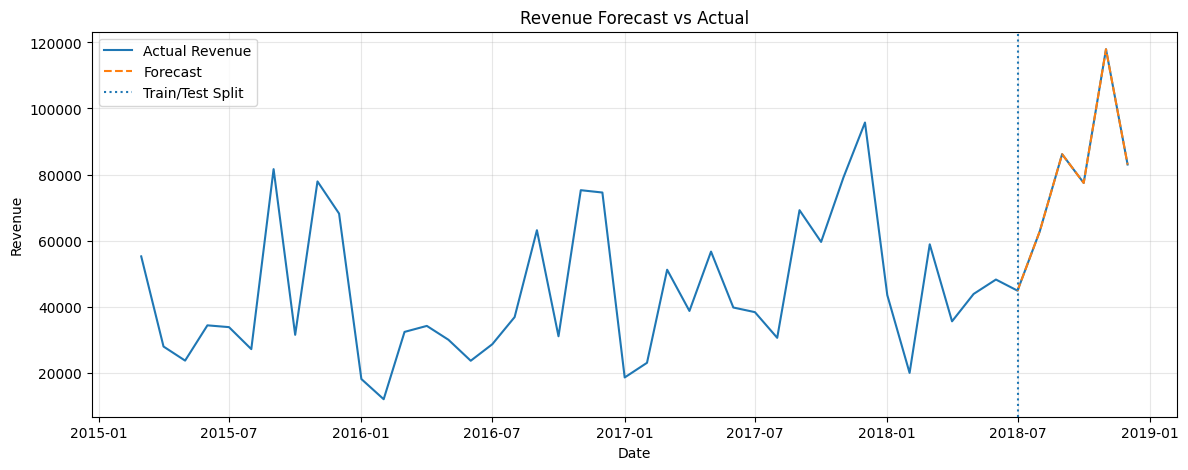

In [101]:
# ============================================================
# FULL FIXED MONTHLY REVENUE + FORECAST PIPELINE
# ============================================================

# ============================================================
# MONTHLY REVENUE QUERY
# ============================================================

monthly = run_query("""

SELECT

    order_year,

    order_month,

    SUM(sales) AS revenue,

    COUNT(DISTINCT order_id) AS orders

FROM orders

GROUP BY
    order_year,
    order_month

ORDER BY
    order_year,
    order_month

""")

# ============================================================
# CHECK DATA
# ============================================================

print(monthly.head())

# ============================================================
# CONVERT TYPES
# ============================================================

monthly['order_year'] = (
    monthly['order_year']
    .astype(str)
)

monthly['order_month'] = (
    monthly['order_month']
    .astype(str)
    .str.zfill(2)
)

# ============================================================
# CREATE DATE COLUMN
# ============================================================

monthly['date'] = pd.to_datetime(

    monthly['order_year']
    + '-'
    + monthly['order_month']
    + '-01'

)

# ============================================================
# SORT BY DATE
# ============================================================

monthly = monthly.sort_values('date')

# ============================================================
# TIME FEATURES
# ============================================================

monthly['month_num'] = range(len(monthly))

monthly['month_of_year'] = (
    monthly['date'].dt.month
)

monthly['quarter'] = (
    monthly['date'].dt.quarter
)

# ============================================================
# LAG FEATURES
# ============================================================

monthly['revenue_lag1'] = (
    monthly['revenue'].shift(1)
)

monthly['revenue_lag2'] = (
    monthly['revenue'].shift(2)
)

# ============================================================
# ROLLING FEATURES
# ============================================================

monthly['rolling3'] = (
    monthly['revenue']
    .rolling(3)
    .mean()
)

# ============================================================
# REMOVE NULLS
# ============================================================

monthly_clean = (
    monthly
    .dropna()
    .reset_index(drop=True)
)

# ============================================================
# CHECK CLEAN DATA
# ============================================================

print("\nMonthly Clean Shape:")
print(monthly_clean.shape)

print("\nMonthly Clean Preview:")
print(monthly_clean.head())

# ============================================================
# FEATURE COLUMNS
# ============================================================

FEATURE_COLS = [

    'month_num',

    'month_of_year',

    'quarter',

    'revenue_lag1',

    'revenue_lag2',

    'rolling3'

]

# ============================================================
# TRAINING DATA
# ============================================================

X_ts = monthly_clean[FEATURE_COLS]

y_ts = monthly_clean['revenue']

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

split_idx = len(monthly_clean) - 6

X_train_ts = X_ts.iloc[:split_idx]

X_test_ts = X_ts.iloc[split_idx:]

y_train_ts = y_ts.iloc[:split_idx]

y_test_ts = y_ts.iloc[split_idx:]

# ============================================================
# TRAIN MODEL
# ============================================================

model_rev = LinearRegression()

model_rev.fit(
    X_train_ts,
    y_train_ts
)

# ============================================================
# PREDICTIONS
# ============================================================

y_pred_ts = model_rev.predict(X_test_ts)

# ============================================================
# EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test_ts,
    y_pred_ts
)

r2 = r2_score(
    y_test_ts,
    y_pred_ts
)

print(f"\nForecast MAE: ${mae:,.0f}")

print(f"Forecast R²: {r2:.3f}")

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(

    monthly_clean['date'],

    y_ts,

    label='Actual Revenue'

)

plt.plot(

    monthly_clean['date'].iloc[split_idx:],

    y_pred_ts,

    linestyle='--',

    label='Forecast'

)

plt.axvline(

    monthly_clean['date'].iloc[split_idx],

    linestyle=':',

    label='Train/Test Split'

)

plt.title('Revenue Forecast vs Actual')

plt.xlabel('Date')

plt.ylabel('Revenue')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [102]:
# ============================================================
# TIME SERIES FEATURE ENGINEERING
# ============================================================

# Sort by date
monthly = monthly.sort_values('date')

# ============================================================
# TIME FEATURES
# ============================================================

monthly['month_num'] = range(len(monthly))

monthly['month_of_year'] = (
    monthly['date'].dt.month
)

monthly['quarter'] = (
    monthly['date'].dt.quarter
)

# ============================================================
# LAG FEATURES
# ============================================================

monthly['revenue_lag1'] = (
    monthly['revenue'].shift(1)
)

monthly['revenue_lag2'] = (
    monthly['revenue'].shift(2)
)

# ============================================================
# ROLLING FEATURES
# ============================================================

monthly['rolling3'] = (
    monthly['revenue']
    .rolling(3)
    .mean()
)

# ============================================================
# REMOVE NaN VALUES
# ============================================================

monthly_clean = (
    monthly
    .dropna()
    .reset_index(drop=True)
)

# ============================================================
# CHECK DATA
# ============================================================

monthly_clean.head()

,order_year,order_month,revenue,orders,date,month_num,month_of_year,quarter,revenue_lag1,revenue_lag2,rolling3
0,2015,03,55205.7970,69,2015-03-01,2,3,1,4519.8920,14205.707,24643.798667
1,2015,04,27906.8550,63,2015-04-01,3,4,2,55205.7970,4519.892,29210.848000
2,2015,05,23644.3030,68,2015-05-01,4,5,2,27906.8550,55205.797,35585.651667
3,2015,06,34322.9356,64,2015-06-01,5,6,2,23644.3030,27906.855,28624.697867
4,2015,07,33781.5430,64,2015-07-01,6,7,3,34322.9356,23644.303,30582.927200


In [103]:
FEATURE_COLS = [
    'month_num',
    'month_of_year',
    'quarter',
    'revenue_lag1',
    'revenue_lag2',
    'rolling3'
]

X_ts = monthly_clean[FEATURE_COLS]

y_ts = monthly_clean['revenue']

Revenue Forecast — MAE: $0  |  R²: 1.000


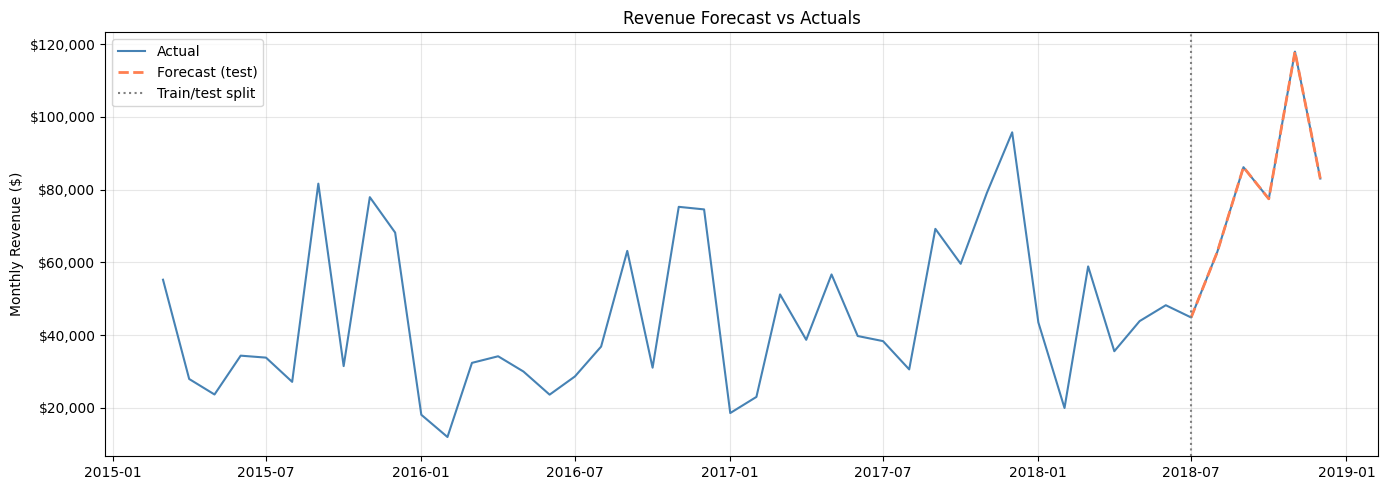

In [104]:
# ============================================================
# CELL 10 — Train model and generate 6-month forecast
# ============================================================

FEATURE_COLS = [
    'month_num', 'month_of_year', 'quarter',
    'revenue_lag1', 'revenue_lag2', 'rolling3'
]

X_ts = monthly_clean[FEATURE_COLS]
y_ts = monthly_clean['revenue']

# Train on all but the last 6 months, test on last 6
split_idx = len(monthly_clean) - 6
X_train_ts, X_test_ts = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
y_train_ts, y_test_ts = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

model_rev = LinearRegression()
model_rev.fit(X_train_ts, y_train_ts)

y_pred_ts = model_rev.predict(X_test_ts)

mae = mean_absolute_error(y_test_ts, y_pred_ts)
r2  = r2_score(y_test_ts, y_pred_ts)
print(f"Revenue Forecast — MAE: ${mae:,.0f}  |  R²: {r2:.3f}")

# Visualise actual vs predicted
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_clean['date'], y_ts, label='Actual', color='steelblue', linewidth=1.5)
ax.plot(monthly_clean['date'].iloc[split_idx:], y_pred_ts,
        label='Forecast (test)', color='coral', linewidth=2, linestyle='--')
ax.axvline(monthly_clean['date'].iloc[split_idx], color='gray',
           linestyle=':', label='Train/test split')
ax.set_title('Revenue Forecast vs Actuals')
ax.set_ylabel('Monthly Revenue ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [105]:
# ============================================================
# CELL 11 — Save all model outputs for the dashboard
# ============================================================

# Save the enriched customer table (feeds Streamlit in Phase 4)
rfm.to_csv('../data/processed/customer_segments.csv', index=False)

# Save monthly with forecast
monthly_clean.to_csv('../data/processed/monthly_revenue.csv', index=False)

print("Saved:")
print("  data/processed/customer_segments.csv")
print("  data/processed/monthly_revenue.csv")
print(f"\nCustomer table columns: {rfm.columns.tolist()}")
print(f"\nFinal dataset shape: {rfm.shape}")

Saved:
  data/processed/customer_segments.csv
  data/processed/monthly_revenue.csv

Customer table columns: ['customer_id', 'recency', 'frequency', 'monetary', 'avg_order', 'first_order', 'last_order', 'n_products', 'n_categories', 'segment', 'region', 'tenure_days', 'avg_days_between_orders', 'category_diversity', 'churned', 'churn_probability', 'churn_risk', 'cluster', 'segment_name']

Final dataset shape: (793, 19)
